# Clase 19: Transformers

**Objetivo:** Comprender la arquitectura Transformer, que abandonó las RNNs y las CNN para basarse únicamente en mecanismos de atención, logrando mayor paralelismo y mejores resultados en tareas de NLP.

En este cuaderno:
1. Problemas de las RNN que motivaron los Transformers.
2. Arquitectura general: encoder y decoder.
3. Componentes clave: atención multi‑cabeza, codificación posicional, feed‑forward, residuales y layer norm.
4. Implementación desde cero en PyTorch.
5. Ejemplo práctico: Transformer para modelado de lenguaje.
6. GPT (decoder puro) y BERT (encoder puro).
7. Ejercicios.

Usaremos **PyTorch** y conjuntos de datos sintéticos para demostración.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import Counter

print("Bibliotecas cargadas.")

Bibliotecas cargadas.


## 1. Motivación: ¿Por qué superar las RNN?

Las RNN (LSTM/GRU) tienen limitaciones:
- **Procesamiento secuencial**: no pueden paralelizarse eficientemente (cada paso depende del anterior).
- **Backpropagation a través del tiempo**: problemas de gradiente desvanecido/explotado.
- **Cuello de botella**: toda la información de la entrada se comprime en un único vector de contexto.

El Transformer propuesto en *Attention Is All You Need* (Vaswani et al., 2017) elimina la recurrencia y utiliza **solo atención**, permitiendo paralelismo total y capturando dependencias a larga distancia.

## 2. Arquitectura general del Transformer

El Transformer (para traducción) tiene un **encoder** y un **decoder**. El encoder procesa la secuencia de entrada y el decoder genera la salida. Ambos están compuestos por bloques apilados.

**Componentes:**
- Atención de múltiples cabezales (Multi‑Head Attention)
- Conexiones residuales y normalización por capas (LayerNorm)
- Red feed‑forward posición a posición (FFN)
- Codificación posicional (Positional Encoding)

Primero implementaremos cada pieza.

## 3. Atención Escalada por Producto Punto (Scaled Dot‑Product Attention)

Es la base de la atención multi‑cabeza:
$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V
$$
Donde $Q$ (queries), $K$ (keys) y $V$ (values) son matrices.

In [5]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, Q, K, V, mask=None):
        d_k = Q.shape[-1]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context = torch.matmul(attn_weights, V)
        return context, attn_weights

## 4. Atención de Múltiples Cabezales (Multi‑Head Attention)

Proyecta Q, K, V a `h` subespacios diferentes, aplica atención en paralelo y concatena los resultados.
$$
\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O
$$
$$
\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)
        self.attention = ScaledDotProductAttention(dropout)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, Q, K, V, mask=None):
        batch_size = Q.shape[0]
        Q = self.W_q(Q).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(K).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(V).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        context, attn_weights = self.attention(Q, K, V, mask)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_dim)
        output = self.W_o(context)
        return output, attn_weights

## 5. Codificación Posicional (Positional Encoding)

Como el Transformer no tiene recurrencia, necesita inyectar información sobre la posición de cada token. Usamos senos y cosenos de diferentes frecuencias:
$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right),
\quad
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

## 6. Red Feed‑Forward (Posición a Posición)

Es una MLP de dos capas aplicada a cada posición de forma independiente:
$$
\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2
$$

In [8]:
class PositionWiseFFN(nn.Module):
    def __init__(self, embed_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, ff_dim)
        self.fc2 = nn.Linear(ff_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()
        
    def forward(self, x):
        return self.fc2(self.dropout(self.activation(self.fc1(x))))

## 7. Bloque Encoder

Cada bloque encoder contiene:
- Multi‑head attention (con conexión residual + layer norm)
- Feed‑forward (con conexión residual + layer norm)

In [9]:
class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.ffn = PositionWiseFFN(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        attn_out, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

## 8. Encoder Completo

Apila varios `EncoderBlock` y añade embedding + codificación posicional.

In [10]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, max_len=5000, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len, dropout)
        self.layers = nn.ModuleList([EncoderBlock(embed_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

## 9. Transformer para Modelado de Lenguaje (decoder puro)

Para tareas generativas (como GPT), se usa solo el decoder con **máscara de causalidad** (para que cada posición no vea el futuro). Implementaremos una versión simplificada para predecir la siguiente palabra.

In [11]:
class CausalSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(embed_dim, num_heads, dropout)
        
    def forward(self, x):
        batch, seq_len, _ = x.shape
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device)).view(1, 1, seq_len, seq_len)
        mask = mask == 1
        out, _ = self.mha(x, x, x, mask)
        return out

class DecoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.self_attn = CausalSelfAttention(embed_dim, num_heads, dropout)
        self.ffn = PositionWiseFFN(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        attn_out = self.self_attn(x)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

class GPT(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, max_len=5000, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len, dropout)
        self.layers = nn.ModuleList([DecoderBlock(embed_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)])
        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)
        
    def forward(self, x):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits

## 10. Ejemplo práctico: Modelado de lenguaje con un dataset sintético

Entrenaremos un pequeño GPT para predecir la siguiente palabra en frases simples.

Epoch 50, Loss: 0.5994
Epoch 100, Loss: 0.6338
Epoch 150, Loss: 0.5342
Epoch 200, Loss: 0.6217


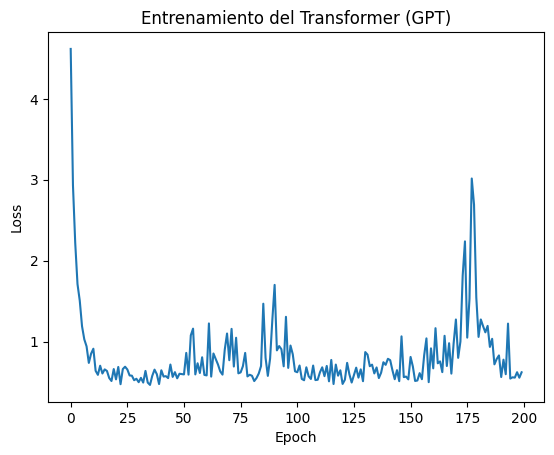

In [12]:
texts = [
    "el gato come pescado",
    "el perro ladra fuerte",
    "la casa es grande",
    "el sol brilla mucho",
    "me gusta programar"
]

words = []
for t in texts:
    words.extend(t.split())
word_counts = Counter(words)
vocab = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
for w in word_counts:
    vocab[w] = len(vocab)
idx_to_word = {v:k for k,v in vocab.items()}
vocab_size = len(vocab)

def encode(sentence, max_len=10):
    tokens = sentence.split()
    indices = [vocab.get(t, vocab['<unk>']) for t in tokens]
    indices = [vocab['<sos>']] + indices + [vocab['<eos>']]
    if len(indices) < max_len:
        indices += [vocab['<pad>']] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return torch.tensor(indices)

max_len = 8
data = []
for t in texts:
    idx = encode(t, max_len)
    data.append(idx)
data = torch.stack(data)

embed_dim = 32
num_heads = 2
ff_dim = 64
num_layers = 2
dropout = 0.1
batch_size = 2
epochs = 200
lr = 0.01

model = GPT(vocab_size, embed_dim, num_heads, ff_dim, num_layers, max_len, dropout)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<pad>'])

losses = []
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for i in range(0, len(data), batch_size):
        x = data[i:i+batch_size, :-1]
        y = data[i:i+batch_size, 1:]
        logits = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / (len(data)//batch_size)
    losses.append(avg_loss)
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Entrenamiento del Transformer (GPT)')
plt.show()

In [13]:
def generate(prompt, model, max_new_tokens=10):
    model.eval()
    tokens = prompt.split()
    indices = [vocab.get(t, vocab['<unk>']) for t in tokens]
    input_seq = torch.tensor([indices])
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(input_seq)
            next_token_logits = logits[0, -1, :]
            next_token = torch.argmax(next_token_logits).item()
            if next_token == vocab['<eos>']:
                break
            indices.append(next_token)
            input_seq = torch.tensor([indices])
    return ' '.join(idx_to_word[i] for i in indices)

print(generate("el gato", model))

el gato come pescado


## 11. GPT vs BERT

- **GPT** (Generative Pre-trained Transformer): decodificador puro, autoregresivo, excelente para generación de texto.
- **BERT** (Bidirectional Encoder Representations from Transformers): encoder puro, bidireccional, ideal para comprensión (clasificación, NER, QA).

Ambos usan la misma arquitectura base pero diferentes objetivos de pre-entrenamiento.

## 12. Ejercicios

1. **Fácil:** Aumente el número de capas del GPT a 4 y observe el cambio en la pérdida.
2. **Fácil:** En la generación, cambie a muestreo por temperatura (softmax con temperatura).
3. **Intermedio:** Implemente un encoder Transformer para clasificación de sentimientos (usando el token CLS).
4. **Difícil:** Añada atención encoder-decoder al GPT para hacer un Transformer completo.

**Entregable:** Entregue al menos dos ejercicios resueltos.

## 13. Resumen

- Transformers: solo atención, paralelismo total.
- Componentes: multi-head attention, positional encoding, FFN, residual + layer norm.
- GPT: decoder, autoregresivo.
- BERT: encoder, bidireccional.

La base de los modelos modernos de lenguaje (LLMs).